In [199]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import sympy as sp
import matplotlib.pyplot as plt

Karakterisztika kiolvasása Abaqus rpt-ból

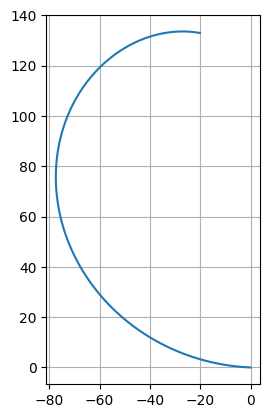

In [200]:
df = pd.read_csv("txtfiles/FEMCHAR.rpt",sep=r"\s+",header=None,engine="python")

arr = df.iloc[1:].astype(float).to_numpy().T

fig, ax1 = plt.subplots()

ax1.grid()
ax1.set_aspect("equal")
ax1.plot(arr[0], arr[1])

plt.show()

Polinom illesztés kimért pozíciókra

-----------------
[ 0. 16. 32. 43. 57. 69. 74.]
[ 0.  1.  7. 13. 27. 39. 61.]
[74. 72. 55.]
[ 61.  83. 113.]
[  0. -19. -33. -45. -56.]
[ 0.  4.  8. 14. 20.]
-----------------
[ 0.01434271 -0.34351258  1.37972875]
------------
------------
[-4.86068111e-01  5.99659443e+01 -1.71477090e+03]
------------
------------
[ 0.00450175 -0.10347867  0.08134529]
------------
------------


C:\Users\Msi\AppData\Local\Temp\ipykernel_10868\3230303836.py:45: OptimizeWarning: Covariance of the parameters could not be estimated
  coeffs2, cov2 = curve_fit(Char_Polynomial2,x2vals,z2vals, maxfev=10000)


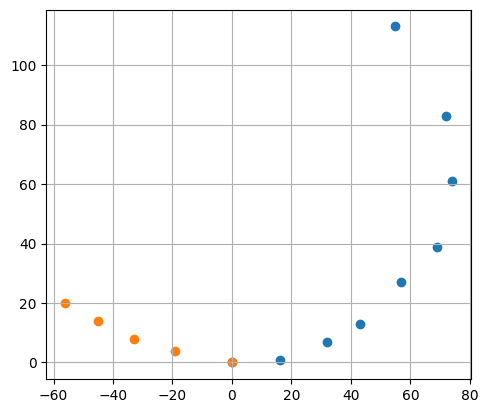

In [201]:
#z = Ax^5+Bx^4+Cx^3+Dx^2+Ex+F - túlnyomás, z'>0
#z = Ax^3+Bx^2+Cx+D - túlnyomás, z'<0
#z = Ax^3+Bx^2+Cx+D - vákuum

p12vals, x12vals, z12vals = np.loadtxt("txtfiles/MEASCHAR1.txt", delimiter="\t", unpack=True)
p3vals, x3vals, z3vals = np.loadtxt("txtfiles/MEASCHAR2.txt", delimiter="\t", unpack=True)

x1vals = x12vals[:7]
x2vals = x12vals[6:]
z1vals= z12vals[:7]
z2vals = z12vals[6:]

print("-----------------")
print(x1vals)
print(z1vals)
print(x2vals)
print(z2vals)
print(x3vals)
print(z3vals)
print("-----------------")

fig2, ax2 = plt.subplots()

ax2.grid()
ax2.set_aspect("equal")
ax2.scatter(x12vals, z12vals)
ax2.scatter(x3vals,z3vals)

def Char_Polynomial6(x,A,B,C,D,E,F,G):
    return A*x**6+B*x**5+C*x**4+D*x**3+E*x**2+F*x+G

def Char_Polynomial5(x,A,B,C,D,E,F):
    return A*x**5+B*x**4+C*x**3+D*x**2+E*x+F

def Char_Polynomial4(x,A,B,C,D,E):
    return A*x**4+B*x**3+C*x**2+D*x+E

def Char_Polynomial3(x,A,B,C,D):
    return A*x**3+B*x**2+C*x+D

def Char_Polynomial2(x,A,B,C):
    return A*x**2+B*x+C

coeffs1, cov1 = curve_fit(Char_Polynomial2,x1vals,z1vals, maxfev=10000)
coeffs2, cov2 = curve_fit(Char_Polynomial2,x2vals,z2vals, maxfev=10000)
coeffs3, cov3 = curve_fit(Char_Polynomial2,x3vals,z3vals, maxfev=10000)

print(coeffs1)
print("------------")
#print(cov1)
print("------------")
print(coeffs2)
print("------------")
#print(cov2)
print("------------")
print(coeffs3)
print("------------")
#print(cov3)
print("------------")


Relatív pozíció plot

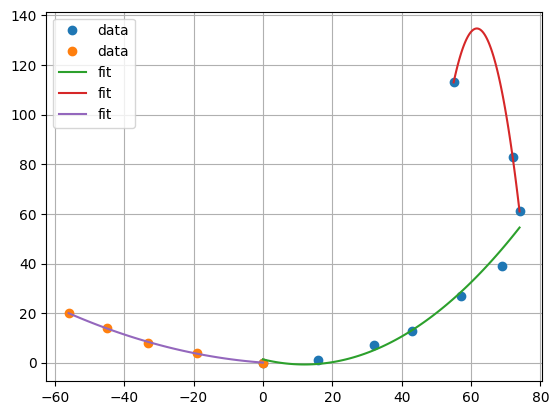

In [202]:
xvals_cont_1 = np.linspace(x1vals[0],x1vals[-1],100)
xvals_cont_2 = np.linspace(x2vals[0],x2vals[-1],100)
xvals_cont_3 = np.linspace(x3vals[0],x3vals[-1],100)

#fit_z1 = Char_Polynomial6(xvals_cont_1, coeffs1[0],coeffs1[1],coeffs1[2],
#                          coeffs1[3],coeffs1[4],coeffs1[5],coeffs1[6])
fit_z1 = Char_Polynomial2(xvals_cont_1, coeffs1[0],coeffs1[1],coeffs1[2],)
fit_z2 = Char_Polynomial2(xvals_cont_2, coeffs2[0],coeffs2[1],coeffs2[2])
fit_z3 = Char_Polynomial2(xvals_cont_3, coeffs3[0],coeffs3[1],coeffs3[2])

fig3, ax3 = plt.subplots()

ax3.plot(x12vals, z12vals, 'o', label='data')
ax3.plot(x3vals, z3vals, 'o', label='data')

ax3.plot(xvals_cont_1, fit_z1, '-', label='fit')
ax3.plot(xvals_cont_2, fit_z2, '-', label='fit')
ax3.plot(xvals_cont_3, fit_z3, '-', label='fit')

ax3.legend()
ax3.grid()
plt.show()

Abszolút pozíció plot

[]

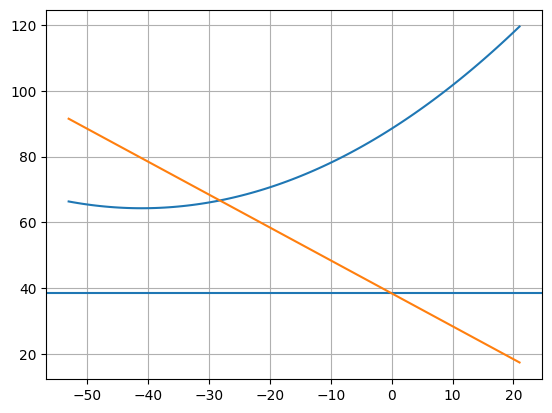

In [203]:
Dc=106#arm inner pitch circle diameter,mm
H0=38.5#height of workpiece base from assembly base,mm
L=135#arm length,mm
H=200#height of encastre end from assembly base,mm
B=22#broadness of arm,mm

fig5, ax5 = plt.subplots()

xvals_cont_1_abs = xvals_cont_1-Dc/2
fit_z1_abs = fit_z1+H-L
zc = -xvals_cont_1_abs+H0


ax5.axhline(H0)
ax5.grid()
ax5.plot(xvals_cont_1_abs, fit_z1_abs, '-', label='fit')
ax5.plot(xvals_cont_1_abs, zc, '-', label='fit')
ax5.plot()

Kör geometria

Minimális megfogható körátmérő

Összezárási pozíció

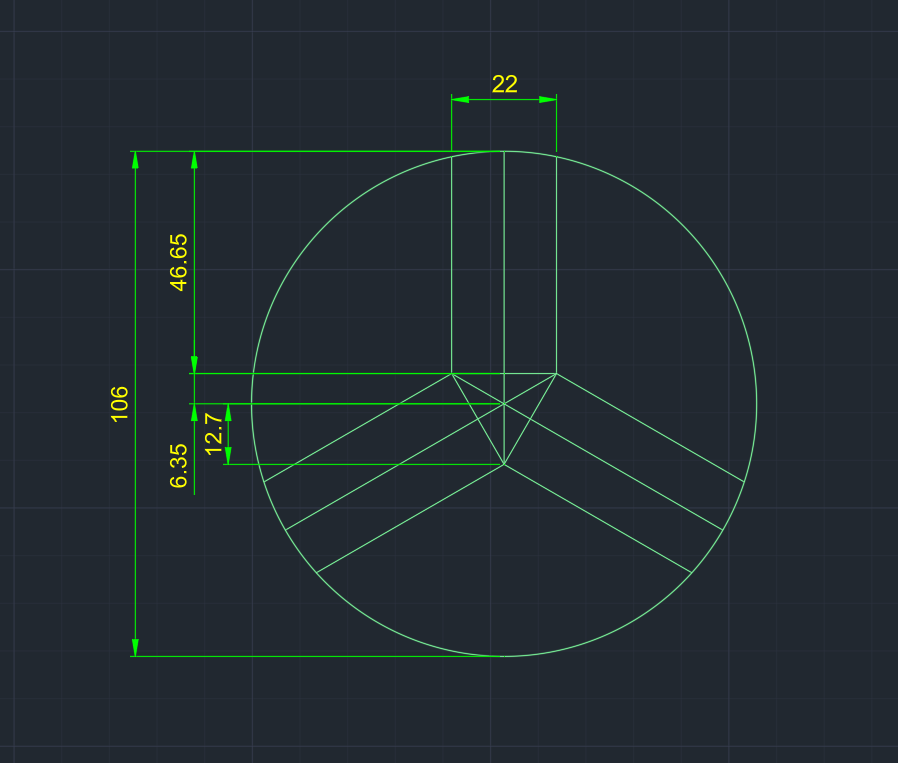

In [204]:
x_cl = Dc/2-B*3**(1/2)/6
print(x_cl)

46.649147038914116


Paraméteres megoldás

In [205]:
x_sym,H0_sym,H_sym,L_sym,Dc_sym,c1,c2,c3 = sp.symbols("x,H0,H,L,Dc,c1,c2,c3")

eq1 = c1*(x_sym+Dc_sym/2)**2+c2*(x_sym+Dc_sym/2)+c3+H_sym-L_sym-H0_sym+x_sym
eq1_num = eq1.subs({H0_sym:H0,H_sym:H,Dc_sym:Dc,L_sym:L,
                    c1: coeffs1[0],c2: coeffs1[1],
                    c3: coeffs1[2]})


sol = sp.solve(eq1_num,x_sym)
#sol = sp.nroots(eq1_num)
print(sol)


x_dm = Dc/2+sol[1]
print(x_dm)

Dmin = abs(sol[1])
print(Dmin)

    

[-123.584708168358, -28.1868096810760]
24.8131903189240
28.1868096810760


Munkatér plot

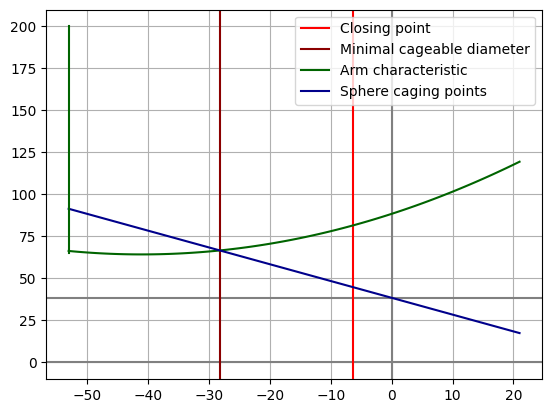

In [206]:
fig6, ax6 = plt.subplots()

ax6.axhline(H0,color="gray")
ax6.axhline(0,color="gray")
ax6.axvline(0,color="gray")
ax6.axvline(-Dc/2+x_cl,color="red",label="Closing point")
ax6.axvline(-Dc/2+x_dm,color="darkred",label="Minimal cageable diameter")
ax6.grid()
ax6.plot(xvals_cont_1_abs, fit_z1_abs, '-',color="darkgreen",label="Arm characteristic")
ax6.plot(xvals_cont_1_abs, zc, '-',color="darkblue",label="Sphere caging points")
ax6.plot([-Dc/2,-Dc/2],[H,H-L],color="darkgreen")
ax6.legend()
#ax6.set_aspect("equal")



Spline illesztés

[ 0. 10. 20. 30. 40. 50. 60. 70. 80.]
[ -5. -10. -15. -20. -25.]
-------------
-------------
[-25. -20. -15. -10.  -5.]
[-56. -45. -33. -19.   0.]
[20. 14.  8.  4.  0.]
-------------
-------------
[-25. -20. -15. -10.  -5.   0.  10.  20.  30.  40.  50.  60.  70.  80.]
[-56. -45. -33. -19.   0.   0.  16.  32.  43.  57.  69.  74.  72.  55.]
[ 20.  14.   8.   4.   0.   0.   1.   7.  13.  27.  39.  61.  83. 113.]
-------------


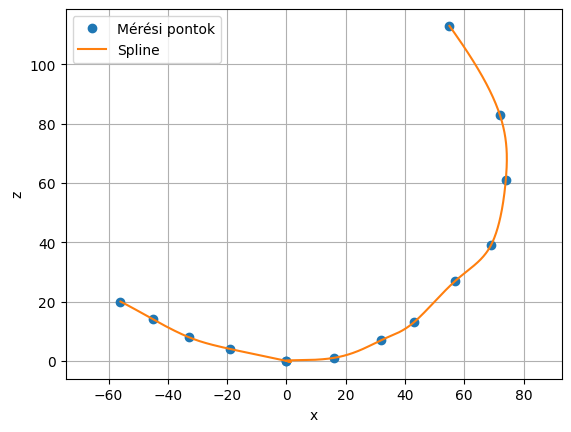

In [207]:
from scipy.interpolate import CubicSpline

print(p12vals)
print(p3vals)
print("-------------")

p3vals = p3vals[::-1]
x3vals = x3vals[::-1]
z3vals = z3vals[::-1]
print("-------------")
print(p3vals)
print(x3vals)
print(z3vals)
print("-------------")
pvals = np.concatenate((p3vals,p12vals))
xvals = np.concatenate((x3vals,x12vals))
zvals = np.concatenate((z3vals,z12vals))
print("-------------")
print(pvals)
print(xvals)
print(zvals)
print("-------------")
sx = CubicSpline(pvals, xvals)
sz = CubicSpline(pvals, zvals)

print(sx)


p_spline = np.linspace(pvals.min(), pvals.max(), 500)

x_vals_spline_rel = sx(p_spline)
z_vals_spline_rel = sz(p_spline)

x_vals_spline_abs = x_vals_spline_rel-Dc/2
z_vals_spline_abs = z_vals_spline_rel+H-L

xvals_cont_1_abs = xvals_cont_1-Dc/2
fit_z1_abs = fit_z1+H-L



fig7,ax7 = plt.subplots()

ax7.plot(xvals, zvals, 'o', label='Mérési pontok')
ax7.plot(x_vals_spline_rel, z_vals_spline_rel, '-', label='Spline')
ax7.set_xlabel('x')
ax7.set_ylabel('z')
ax7.axis('equal')
ax7.legend()
ax7.grid()

Spline munkatér plot

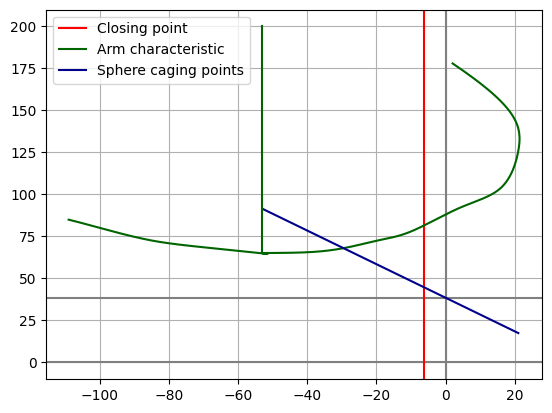

In [208]:
fig8, ax8 = plt.subplots()

ax8.axhline(H0,color="gray")
ax8.axhline(0,color="gray")
ax8.axvline(0,color="gray")
ax8.axvline(-Dc/2+x_cl,color="red",label="Closing point")
ax8.grid()
ax8.plot(x_vals_spline_abs, z_vals_spline_abs, '-',color="darkgreen",label="Arm characteristic")
ax8.plot(xvals_cont_1_abs, zc, '-',color="darkblue",label="Sphere caging points")
ax8.plot([-Dc/2,-Dc/2],[H,H-L],color="darkgreen")
ax8.legend()
#ax6.set_aspect("equal")

Spline metszéspont számítása

In [209]:
from scipy.optimize import brentq


def wp_sphere(p):
    x_abs = sx(p) - Dc/2
    z_abs = sz(p) + H - L
    
    return z_abs - (-x_abs + H0)

p_dm = brentq(wp_sphere, pvals.min(), pvals.max())

print(pvals.min())
print(pvals.max())

x_dm_spline_rel = sx(p_dm)
z_dm_spline_rel = sz(p_dm)

print("p =", p_dm)
print("x =", x_dm_spline_rel)
print("z =", z_dm_spline_rel)

x_dm_spline_abs = x_dm_spline_rel-Dc/2

print(x_dm_spline_abs)

-25.0
80.0
p = 13.914763068822813
x = 23.46028372514975
z = 3.039716274850258
-29.53971627485025


Spline metszéspont plot

C:\Users\Msi\AppData\Local\Temp\ipykernel_10868\4279483899.py:10: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax9.plot(xvals_cont_1_abs,fit_z1_abs, '-',color="purple",linestyle="--",label="Arm characteristic - poly")


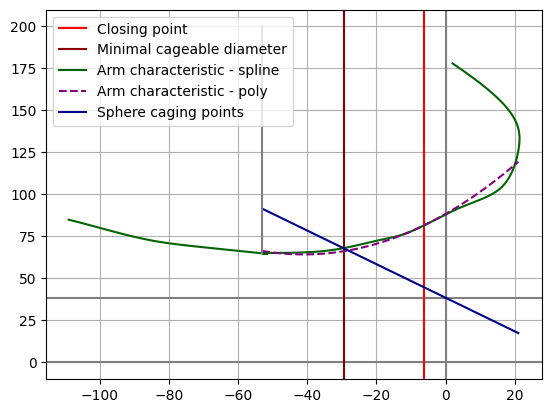

In [210]:
fig9, ax9 = plt.subplots()

ax9.axhline(H0,color="gray")
ax9.axhline(0,color="gray")
ax9.axvline(0,color="gray")
ax9.axvline(x_cl-Dc/2,color="red",label="Closing point")
ax9.axvline(x_dm_spline_abs,color="darkred",label="Minimal cageable diameter")
ax9.grid()
ax9.plot(x_vals_spline_abs, z_vals_spline_abs, '-',color="darkgreen",label="Arm characteristic - spline")
ax9.plot(xvals_cont_1_abs,fit_z1_abs, '-',color="purple",linestyle="--",label="Arm characteristic - poly")
ax9.plot(xvals_cont_1_abs, zc, '-',color="darkblue",label="Sphere caging points")
ax9.plot([-Dc/2,-Dc/2],[H,H-L],color="gray")
ax9.legend()
#ax6.set_aspect("equal")

Minimális megfogható hengerátmérő

In [211]:
H02 = 75

def wp_cyl(p):
    z_abs = sz(p) + H - L

    return z_abs - H02

print("f(p_min) =", wp_cyl(pvals.min()))
print("f(p_max) =", wp_cyl(pvals.max()))
p_dm = brentq(wp_cyl, 0, pvals.max())

print(pvals.min())
print(pvals.max())


x_dm_spline_rel = sx(p_dm)
z_dm_spline_rel = sz(p_dm)

print("p =", p_dm)
print("x =", x_dm_spline_rel)
print("z =", z_dm_spline_rel)

x_dm_spline_abs = x_dm_spline_rel - Dc/2
z_dm_spline_abs = z_dm_spline_rel + H - L

print("x_abs =", x_dm_spline_abs)
print("z_abs =", z_dm_spline_abs)

f(p_min) = 10.0
f(p_max) = 103.0
-25.0
80.0
p = 26.152294095227116
x = 38.661452423890104
z = 10.000000000000004
x_abs = -14.338547576109896
z_abs = 75.0


Spline metszési pont

C:\Users\Msi\AppData\Local\Temp\ipykernel_10868\550757544.py:10: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax9.plot(xvals_cont_1_abs,fit_z1_abs, '-',color="purple",linestyle="--",label="Arm characteristic - poly")


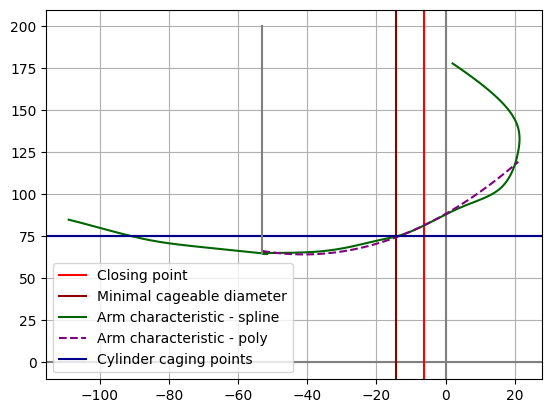

In [212]:
fig9, ax9 = plt.subplots()

ax9.axhline(H02,color="gray")
ax9.axhline(0,color="gray")
ax9.axvline(0,color="gray")
ax9.axvline(x_cl-Dc/2,color="red",label="Closing point")
ax9.axvline(x_dm_spline_abs,color="darkred",label="Minimal cageable diameter")
ax9.grid()
ax9.plot(x_vals_spline_abs, z_vals_spline_abs, '-',color="darkgreen",label="Arm characteristic - spline")
ax9.plot(xvals_cont_1_abs,fit_z1_abs, '-',color="purple",linestyle="--",label="Arm characteristic - poly")
ax9.axhline(H02,linestyle='-',color="darkblue",label="Cylinder caging points")
ax9.plot([-Dc/2,-Dc/2],[H,H-L],color="gray")
ax9.legend()
#ax6.set_aspect("equal")